# Create ESM25 HDF5 Waveform & Spectra Files — remove strategy

**Authors:** Spina Cianetti (def wf_Resample by Claudia Mascandola)

**License:** [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/)  
This work is shared under a Creative Commons Attribution-ShareAlike 4.0 International license.

**Repository:** European Strong-Motion Database (ESM-DB)

---

This notebook creates consolidated HDF5 files from per-event ASDF files of the ESM25 dataset.  
Each record is indexed by name (`source_id.network.station.location.channel`) and accompanied by data-format metadata.

## Workflow structure

1. **Setup** — environment variables and imports
2. **Helper functions** — ASDF trace lookup, HDF5 data-format writing, component ordering, resampling, zero-padding (back-pad and front-pad)
3. **Global configuration** — paths and processing parameters shared by all datasets
4. **Sequential pipeline** — runs automatically for `bad`, then `good_cv`, then `good_mp`:
   - 4.1 Helper functions for the pipeline (metadata loading, HDF5 creation, temporal join, missing-records analysis)
   - 4.2 Sequential pipeline execution
   - 4.3 Front-padding alignment — aligns CV components (u, v, w) and the corresponding MP waveform to a unified start time by prepending zeros
5. **HDF5 spectra creation** — reads response spectra from `AuxiliaryData/Spectra` in each ASDF file and writes `spectra_all.h5`
   - 5.1 Final alignment — intersection cv ∩ mp ∩ spectra → shared `metadata_final.csv`
6. **Output file verification** — consistency checks on HDF5 files and final metadata
7. **Quick waveform plot** — sample trace inspection
8. **Quick HDF5 structure inspection** — dataset listing for a sanity check

## Waveform processing

| Dataset    | Trace type      | Resampling | Target duration | Target samples | Longer traces |
|------------|-----------------|------------|-----------------|----------------|---------------|
| bad        | acc_cv          | to 200 Hz  | 420 s           | 84,000         | discarded     |
| good_cv    | acc_cv          | to 200 Hz  | 420 s           | 84,000         | discarded     |
| good_mp    | acc/vel/dis_mp  | none (already 200 Hz) | 420 s | 84,000       | discarded     |

- Padding is performed with **zeros**; the `trace_has_padding` column in the CSV flags extended records.
- Temporal metadata (`start_time`, `end_time`, `duration_s`, `dt_s`) are read from
  `waveform_summary.csv` (produced by `Extract_waveform_parameters.ipynb`) via join,
  **not from HDF5 attributes** (which were absent for most traces).

## Front-padding alignment (Section 4.3)

After the sequential pipeline, the three CV components (u, v, w) of a given record may have different original start times. The front-padding step:

1. Identifies the **earliest** start time across u, v, w and stores it as `trace_start_time`.
2. **Front-pads** each CV channel with zeros so that all three begin at `trace_start_time`.
3. **Front-pads** the corresponding MP waveform (all 9 components) to the same `trace_start_time`.
4. Re-applies back-padding (`pad_or_trim`) to maintain the fixed target length.
5. Rewrites the HDF5 files in place with the aligned waveforms.

Original per-component temporal metadata is preserved with the `_orig_` naming convention:

- `trace_start_time_orig_cv_u/v/w`, `trace_end_time_orig_cv_u/v/w`, `trace_duration_s_orig_cv_u/v/w`
- `trace_dt_s_orig_cv_u` (representative; identical across components after resampling)
- `trace_start_time_orig_mp`, `trace_end_time_orig_mp`, `trace_duration_s_orig_mp`, `trace_dt_s_orig_mp`

After resampling, the unified `trace_dt_s` column is set to `1 / trace_sampling_rate_hz` (0.005 s at 200 Hz).

---


## 1. Setup: environment variables and imports

In [2]:
import os

# Disable HDF5 file locking (required on network/NFS filesystems)
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [3]:
import shutil
import tempfile
from fractions import Fraction

import h5py
import numpy as np
import pandas as pd
import pyasdf
from scipy.signal import resample_poly

## 2. Helper functions

### 2.1 ASDF group and trace lookup

In [4]:
# Valid suffixes for trace type
VALID_SUFFIXES = ["acc_cv", "acc_mp", "vel_mp", "dis_mp"]

# Networks with a different code in the ASDF (stored as 'IV')
SPECIAL_NETS = {"8H", "5G", "8P", "9N"}

# Number of spectral components: 3 acc_mp + 3 dis_mp
N_SPECTRA_COMPONENTS = 6


def normalize_source_id(source_id):
    """Normalise the sourceID to lowercase with underscores (format used in spectra datasets).

    Example: 'IT-2016-0001' â†’ 'it_2016_0001'
    """
    return source_id.replace("-", "_").lower()


def find_spectra_group(spectra_root, net, sta):
    """Search for the '<net>_<sta>' sub-group inside AuxiliaryData/Spectra."""
    key = f"{net}_{sta}"
    return spectra_root[key] if key in spectra_root else None


def find_group_for_net_sta(waveforms_grp, net, sta):
    """Search the Waveforms group for a sub-group whose name starts with 'net.sta'."""
    if waveforms_grp is None:
        return None
    prefix = f"{net}.{sta}"
    for grp_name in waveforms_grp:
        if grp_name.startswith(prefix):
            return waveforms_grp[grp_name]
    return None


def find_all_traces_in_group(group, net, sta, loc, ch_u, ch_v, ch_w, debug=False):
    """Return a dict {comp_key: trace_name} for all components.

    Search for traces matching net.sta.loc and the three components (u/v/w)
    for each valid suffix (acc_cv, acc_mp, vel_mp, dis_mp).
    """
    net_sta_loc = f"{net}.{sta}.{loc}"
    out = {f"{suf}_{axis}": None
           for suf in VALID_SUFFIXES
           for axis in ["u", "v", "w"]}

    for trace_name in group.keys():
        if net_sta_loc not in trace_name:
            continue
        suffix = next((suf for suf in VALID_SUFFIXES if suf in trace_name), None)
        if suffix is None:
            continue
        if ch_u in trace_name:
            out[f"{suffix}_u"] = trace_name
        elif ch_v in trace_name:
            out[f"{suffix}_v"] = trace_name
        elif ch_w in trace_name:
            out[f"{suffix}_w"] = trace_name

    if debug:
        print("Traces found:")
        for k, v in out.items():
            print(f"  {k} â†’ {v}")

    return out


def find_all_traces_in_group_net(group, real_net, sta, loc, ch_u, ch_v, ch_w, debug=False):
    """Like find_all_traces_in_group but uses 'real_net' (actual network code in the ASDF).

    Useful for networks in SPECIAL_NETS, stored as 'IV' in the ASDF
    but carrying a different code in the metadata.
    """
    return find_all_traces_in_group(group, real_net, sta, loc, ch_u, ch_v, ch_w, debug=debug)

### 2.2 HDF5 data-format writing functions

In [5]:
def _write_data_format(h5file, group_name, data_format_dict):
    """Create or update a format group in an HDF5 file."""
    grp = h5file.require_group(group_name)
    for key, value in data_format_dict.items():
        if key in grp:
            del grp[key]
        grp.create_dataset(key, data=value)
    return data_format_dict


def add_data_format_info_3(h5file, data_in_counts=True):
    """Write the data-format group for 3-component files (acc_cv only)."""
    data_format = {
        "dimension_order": "CW",
        "component_order": ["acc_cv_u", "acc_cv_v", "acc_cv_w"],
        "measurement": "acceleration",
        "instrument_response": "not restituted" if data_in_counts else "restituted",
        "unit": "counts" if data_in_counts else "cps2",
        "trace_length_samples": 84000,
        "trace_length_s": 420,
        "padding_value": 0,
    }
    return _write_data_format(h5file, "data_format", data_format)


def add_data_format_info_9(h5file, data_in_counts=True):
    """Write the data-format group for 9-component files (acc/vel/dis from mp)."""
    data_format = {
        "dimension_order": "CW",
        "component_order": [
            "acc_mp_u", "acc_mp_v", "acc_mp_w",
            "vel_mp_u", "vel_mp_v", "vel_mp_w",
            "dis_mp_u", "dis_mp_v", "dis_mp_w",
        ],
        "measurement": "acceleration,velocity,displacement",
        "instrument_response": "not restituted" if data_in_counts else "restituted",
        "unit": "counts" if data_in_counts else "cps2/cps/c",
        "trace_length_samples": 84000,
        "trace_length_s": 420,
        "padding_value": 0,
    }
    return _write_data_format(h5file, "data_format", data_format)


def add_data_format_info_12(h5file, data_in_counts=True):
    """Write the data-format group for 12-component files (acc_cv + acc/vel/dis from mp)."""
    data_format = {
        "dimension_order": "CW",
        "component_order": [
            "acc_cv_u", "acc_cv_v", "acc_cv_w",
            "acc_mp_u", "acc_mp_v", "acc_mp_w",
            "vel_mp_u", "vel_mp_v", "vel_mp_w",
            "dis_mp_u", "dis_mp_v", "dis_mp_w",
        ],
        "measurement": "acceleration,velocity,displacement",
        "instrument_response": "not restituted" if data_in_counts else "restituted",
        "unit": "counts" if data_in_counts else "cps2/cps/c",
        "padding_value": 0,
    }
    return _write_data_format(h5file, "data_format", data_format)


def add_spectra_format_info_12(h5file, data_in_counts=True):
    """Write the spectra-format group (6 components: acc and dis from mp)."""
    data_format = {
        "dimension_order": "CW",
        "component_order": [
            "acc_mp_u", "acc_mp_v", "acc_mp_w",
            "dis_mp_u", "dis_mp_v", "dis_mp_w",
        ],
        "measurement": "acceleration,displacement",
        "instrument_response": "not restituted" if data_in_counts else "restituted",
        "unit": "counts" if data_in_counts else "cps2/c",
    }
    return _write_data_format(h5file, "spectra_format", data_format)

### 2.3 Component ordering constants

In [6]:
COMPONENT_ORDER_3 = [
    "acc_cv_u", "acc_cv_v", "acc_cv_w",
]

COMPONENT_ORDER_9 = [
    "acc_mp_u", "acc_mp_v", "acc_mp_w",
    "vel_mp_u", "vel_mp_v", "vel_mp_w",
    "dis_mp_u", "dis_mp_v", "dis_mp_w",
]

COMPONENT_ORDER_12 = COMPONENT_ORDER_3 + COMPONENT_ORDER_9

### 2.4 Resampling to 200 Hz

In [7]:
def wf_Resample(arrays, proc_dt, dt):
    """Resample a list of numpy arrays to the target sampling rate.

    - UPSAMPLING  (proc_dt < dt): scipy.interpolate.interp1d with kind='linear'
    - DOWNSAMPLING (proc_dt > dt): scipy.signal.resample_poly with rational fraction p/q

    Args:
        arrays (list[np.ndarray]): list of 1-D float arrays (the three components).
        proc_dt (float): TARGET time step in seconds (e.g. 0.005 â†’ 200 Hz).
        dt (float): ORIGINAL time step in seconds.

    Returns:
        list[np.ndarray]: list of resampled arrays.
    """
    from fractions import Fraction
    from scipy.interpolate import interp1d
    from scipy.signal import resample_poly

    resampled = []

    if proc_dt < dt:  # UPSAMPLING
        for arr in arrays:
            if len(arr) == 0:
                resampled.append(arr)
                continue
            n_orig   = len(arr)
            t_orig   = np.arange(n_orig) * dt
            n_new    = int(np.floor(t_orig[-1] / proc_dt)) + 1
            t_new    = np.arange(n_new) * proc_dt
            t_new    = t_new[t_new <= t_orig[-1] + 1e-10]
            f_interp = interp1d(t_orig, arr.astype(float), kind='linear',
                                bounds_error=False, fill_value='extrapolate')
            resampled.append(f_interp(t_new).astype(np.float32))

    elif proc_dt > dt:  # DOWNSAMPLING
        target_fs = 1.0 / proc_dt
        orig_fs   = 1.0 / dt
        frac      = Fraction(int(target_fs), int(orig_fs)).limit_denominator(1000)
        up, down  = frac.numerator, frac.denominator
        for arr in arrays:
            if len(arr) == 0:
                resampled.append(arr)
                continue
            resampled.append(resample_poly(arr.astype(float), up, down).astype(np.float32))

    else:  # nessun resampling
        resampled = [arr.astype(np.float32) for arr in arrays]

    return resampled

### 2.5 Zero-padding functions

- `pad_or_trim`: back-padding to fixed length (traces longer than target are discarded)
- `front_pad_to_starttime`: front-padding to align to a reference start time

In [8]:
def pad_or_trim(array, target_npts):
    """Bring a 1-D array to exactly target_npts samples.

    - len < target: zero-pad on the right
    - len == target: no change
    - len > target: do NOT call this function (the trace must already have been discarded)

    Returns:
        tuple[np.ndarray, bool]: (processed array, True if padding was added)
    """
    n = len(array)
    if n == target_npts:
        return array.astype(np.float32), False
    elif n < target_npts:
        padded = np.zeros(target_npts, dtype=np.float32)
        padded[:n] = array
        return padded, True
    else:
        # Should never reach this branch in v11 (traces longer than target are discarded)
        raise ValueError(f"Array length {n} > target {target_npts}: must be discarded before calling this function.")


def front_pad_to_starttime(array, current_starttime, target_starttime, dt):
    """Prepend zeros so that the trace starts at target_starttime.

    Args:
        array (np.ndarray): 1-D float array.
        current_starttime (str): ISO-format start time of this trace.
        target_starttime (str): ISO-format earliest start time to align to.
        dt (float): sampling interval in seconds.

    Returns:
        np.ndarray: front-padded array (or original if no padding needed).
        int: number of samples prepended.
    """
    from obspy import UTCDateTime
    t_current = UTCDateTime(current_starttime)
    t_target  = UTCDateTime(target_starttime)
    delta_s   = t_current - t_target  # positive if current is later than target
    if delta_s <= 0:
        return array.astype(np.float32), 0
    n_prepend = int(round(delta_s / dt))
    if n_prepend == 0:
        return array.astype(np.float32), 0
    padded = np.concatenate([np.zeros(n_prepend, dtype=np.float32), array.astype(np.float32)])
    return padded, n_prepend


## 3. Global configuration

Set paths and shared parameters here. The pipeline will then run automatically  
for **bad → good_cv → good_mp** in sequence, followed by the spectra step.

| Dataset    | Output file            | Comp | Target   | Target npts | Notes                                               |
|------------|------------------------|------|----------|-------------|-----------------------------------------------------|
| `bad`      | `waveforms_bad_cv.h5`       | 3    | 420 s    | 84 000      | Resample to 200 Hz + pad (traces > target discarded) |
| `good_cv`  | `waveforms_good_cv.h5` | 3    | 420 s    | 84 000      | Resample to 200 Hz + pad (traces > target discarded) |
| `good_mp`  | `waveforms_good_mp.h5` | 9    | 420 s    | 84 000      | Already at 200 Hz, zero-pad only (traces > target discarded) |
| `spectra`  | `spectra_all.h5`       | 6    | —        | —           | Response spectra from AuxiliaryData/Spectra          |


## 4. Sequential pipeline: bad → good_cv → good_mp

The following cells define helper functions for each pipeline step  
and then execute them in sequence for all three datasets.

### 4.1 Helper functions for the pipeline

In [9]:
# ============================================================
# GLOBAL CONFIGURATION — adjust these parameters as needed
# ============================================================

# Source directory containing per-event HDF5 (ASDF) files
INPUT_DIR  = "/home/jovyan/shared/users/spina/ESM25/output/"
# Destination directory for consolidated HDF5 files
OUTPUT_DIR = "/home/jovyan/shared/users/spina/ESM25/h5_all_v4/"

# CSV produced by Extract_waveform_parameters.ipynb
WAVE_SUMMARY_CSV = "/home/jovyan/ESM25/waveform_summary.csv"

# Data already restituted in physical units (False = restituted)
DATA_IN_COUNTS = False

# Target sampling rate and corresponding time step
TARGET_FS = 200.0
TARGET_DT = 1.0 / TARGET_FS  # 0.005 s

# ============================================================

DTYPE_MAP = {
    'station_code':           str,
    'station_network_code':   str,
    'station_channel_code':   str,
    'station_location_code':  str,
    'trace_u_channel_code':   str,
    'trace_v_channel_code':   str,
    'trace_w_channel_code':   str,
}

DATASET_CONFIG = {
    'bad': {
        'metadata_csv':    'metadata_bad.csv',
        'metadata_clean':  os.path.join(OUTPUT_DIR, 'metadata_bad_clean.csv'),
        'metadata_final':  os.path.join(OUTPUT_DIR, 'metadata_bad_final.csv'),
        'output_file':     os.path.join(OUTPUT_DIR, 'waveforms_bad_cv.h5'),
        'format_func':     add_data_format_info_3,
        'comp_order':      COMPONENT_ORDER_3,
        'do_resample':     True,
        'target_npts':     84000,
        'target_s':        420,
        'processing_tag':  'cv',
        'padding_col':     'trace_has_padding_cv',
        'ch_u_col':        'trace_u_channel_code',
        'ch_v_col':        'trace_v_channel_code',
        'ch_w_col':        'trace_w_channel_code',
    },
    'good_cv': {
        'metadata_csv':     'metadata_good.csv',
        'metadata_clean':   os.path.join(OUTPUT_DIR, 'metadata_good_clean.csv'),
        'metadata_spectra': 'metadata_good.csv',
        'metadata_final':   os.path.join(OUTPUT_DIR, 'metadata_final.csv'),
        'output_file':      os.path.join(OUTPUT_DIR, 'waveforms_good_cv.h5'),
        'format_func':      add_data_format_info_3,
        'comp_order':       COMPONENT_ORDER_12[:3],
        'do_resample':      True,
        'target_npts':      84000,
        'target_s':         420,
        'processing_tag':   'cv',
        'padding_col':      'trace_has_padding_cv',
        'ch_u_col':         'trace_u_channel_code',
        'ch_v_col':         'trace_v_channel_code',
        'ch_w_col':         'trace_w_channel_code',
    },
    'good_mp': {
        'metadata_csv':     'metadata_good.csv',
        'metadata_clean':   os.path.join(OUTPUT_DIR, 'metadata_good_clean.csv'),
        'metadata_spectra': 'metadata_good.csv',
        'metadata_final':   os.path.join(OUTPUT_DIR, 'metadata_final.csv'),
        'output_file':      os.path.join(OUTPUT_DIR, 'waveforms_good_mp.h5'),
        'format_func':      add_data_format_info_9,
        'comp_order':       COMPONENT_ORDER_12[3:],
        'do_resample':      False,
        'target_npts':      84000,
        'target_s':         420,
        'processing_tag':   'mp',
        'starttime_col':    'trace_start_time_orig_mp',
        'endtime_col':      'trace_end_time_orig_mp',
        'duration_col':     'trace_duration_s_orig_mp',
        'dt_col':           'trace_dt_s_orig_mp',
        'padding_col':      'trace_has_padding_mp',
        'npts_col':         'trace_npts_mp',
    },
}

# Pipeline execution order
PIPELINE_ORDER = ['bad', 'good_cv', 'good_mp']

print("Global configuration loaded.")
print(f"Pipeline order: {' → '.join(PIPELINE_ORDER)} → spectra")
print(f"Input dir    : {INPUT_DIR}")
print(f"Output dir   : {OUTPUT_DIR}")


Global configuration loaded.
Pipeline order: bad → good_cv → good_mp → spectra
Input dir    : /home/jovyan/shared/users/spina/ESM25/output/
Output dir   : /home/jovyan/shared/users/spina/ESM25/h5_all_v4/


In [10]:
def load_metadata(cfg):
    _csv_to_load = cfg['metadata_clean'] if os.path.exists(cfg['metadata_clean']) else cfg['metadata_csv']
    print(f"  CSV loaded          : {_csv_to_load}")

    df_meta = pd.read_csv(
        _csv_to_load,
        low_memory=False,
        index_col=False,
        dtype=DTYPE_MAP,
    )
    df_meta = df_meta.fillna("")
    df_meta['trace_name'] = df_meta['trace_name'].astype(str).str.strip()

    # Columns by component (CV) or aggregated (MP)
    if cfg['processing_tag'] == 'cv':
        # Per-component columns with _orig_ naming
        new_cols = []
        for axis in ['u', 'v', 'w']:
            new_cols += [
                (f'trace_start_time_orig_cv_{axis}',  None),
                (f'trace_end_time_orig_cv_{axis}',    None),
                (f'trace_duration_s_orig_cv_{axis}',  np.nan),
                (f'trace_npts_cv_{axis}',             np.nan),
            ]
        # dt_s_orig only for u (representative)
        new_cols.append(('trace_dt_s_orig_cv_u', np.nan))
        # padding, sampling rate, and unified dt_s
        new_cols += [
            (cfg['padding_col'], False),
            ('trace_sampling_rate_hz', np.nan),
            ('trace_dt_s', np.nan),
        ]
    else:
        # MP: aggregated columns with _orig_ naming
        new_cols = [
            (cfg['starttime_col'], None),
            (cfg['endtime_col'],   None),
            (cfg['duration_col'],  np.nan),
            (cfg['dt_col'],        np.nan),
            (cfg['padding_col'],   False),
            (cfg['npts_col'],      np.nan),
            ('trace_sampling_rate_hz', np.nan),
            ('trace_dt_s', np.nan),
        ]

    new_col_data = {}
    for col, default in new_cols:
        if col not in df_meta.columns:
            new_col_data[col] = default
    if new_col_data:
        df_meta = pd.concat(
            [df_meta, pd.DataFrame(new_col_data, index=df_meta.index)],
            axis=1
        )

    print(f"  Rows loaded         : {len(df_meta):,}")
    print(f"  Unique events       : {df_meta['source_esm_id'].nunique():,}")
    return df_meta


def run_hdf5_waveform(cfg, df_meta):
    """
    Main HDF5 creation loop: iterates over events, extracts traces from ASDF files,
    applies resampling and padding, and writes to the consolidated HDF5 output.
    Returns the filtered df_meta_clean (rows that were successfully written).
    """
    rows_to_keep  = []
    npts_updates  = {}
    pad_updates   = {}
    sr_updates    = {}
    n_written     = 0
    n_missing     = 0
    n_no_group    = 0
    n_too_long    = 0

    comp_order  = cfg['comp_order']
    do_resample = cfg['do_resample']
    target_npts = cfg['target_npts']
    padding_col = cfg['padding_col']
    npts_col      = cfg.get('npts_col')          # None for CV, used only for MP
    is_cv         = cfg['processing_tag'] == 'cv'

    with h5py.File(cfg['output_file'], "w") as f_out:
        data_grp = f_out.create_group("data")
        cfg['format_func'](f_out, DATA_IN_COUNTS)

        for source_id in df_meta['source_esm_id'].unique():
            file_h5 = os.path.join(INPUT_DIR, f"{source_id}.h5")
            if not os.path.exists(file_h5):
                print(f"[MISSING] H5 file not found: {file_h5}")
                n_missing += 1
                continue

            df_event = df_meta[df_meta['source_esm_id'] == source_id]

            with pyasdf.ASDFDataSet(file_h5, mode='r', mpi=False) as ds:
                waveforms_grp = ds._waveform_group

                for idx, row in df_event.iterrows():
                    net       = row['station_network_code']
                    sta       = row['station_code']
                    loc       = row['station_location_code'] if row['station_location_code'] else ""
                    ch_prefix = row['station_channel_code']
                    ch_u      = ch_prefix + row['trace_u_channel_code']
                    ch_v      = ch_prefix + row['trace_v_channel_code']
                    ch_w      = ch_prefix + row['trace_w_channel_code']

                    group    = find_group_for_net_sta(waveforms_grp, net, sta)
                    real_net = net

                    if group is None and net in SPECIAL_NETS:
                        group = find_group_for_net_sta(waveforms_grp, "IV", sta)
                        if group is not None:
                            real_net = "IV"

                    if group is None:
                        print(f"[NO GROUP] {source_id}.{net}.{sta}")
                        n_no_group += 1
                        continue

                    rows_to_keep.append(row.name)

                    traces = find_all_traces_in_group_net(
                        group, real_net, sta, loc, ch_u, ch_v, ch_w, debug=False
                    )

                    trace_arrays = []
                    for comp in comp_order:
                        tname = traces.get(comp)
                        arr   = group[tname][()] if (tname is not None and tname in group) else np.array([], dtype=np.float32)
                        trace_arrays.append(arr.astype(np.float32))

                    # Per-component original npts (CV) or single value (MP)
                    npts_per_comp = {
                        axis: len(arr)
                        for axis, arr in zip(['u', 'v', 'w'], trace_arrays)
                    }

                    if do_resample:
                        sampling_rate = np.nan
                        for comp in comp_order:
                            tname = traces.get(comp)
                            if tname is not None and tname in group:
                                try:
                                    sampling_rate = float(group[tname].attrs.get('sampling_rate', np.nan))
                                except Exception:
                                    pass
                                break
                        if not np.isnan(sampling_rate) and sampling_rate > 0:
                            dt_orig = 1.0 / sampling_rate
                            if abs(dt_orig - TARGET_DT) > 1e-9:
                                trace_arrays = wf_Resample(trace_arrays, TARGET_DT, dt_orig)

                    max_len = max((len(arr) for arr in trace_arrays if len(arr) > 0), default=0)
                    if max_len > target_npts:
                        n_too_long += 1
                        rows_to_keep.pop()
                        continue

                    padded_arrays = []
                    any_padding   = False
                    for arr in trace_arrays:
                        out_arr, had_pad = pad_or_trim(arr, target_npts)
                        padded_arrays.append(out_arr)
                        if had_pad:
                            any_padding = True

                    combined = np.stack(padded_arrays, axis=0)

                    ch_short     = ch_prefix[:2]
                    dataset_name = f"{source_id}.{net}.{sta}.{loc}.{ch_short}"

                    if dataset_name in data_grp:
                        del data_grp[dataset_name]
                    data_grp.create_dataset(dataset_name, data=combined)
                    n_written += 1

                    npts_updates[row.name] = npts_per_comp
                    pad_updates[row.name]  = any_padding
                    sr_updates[row.name]   = TARGET_FS

    print("  " + "=" * 58)
    print(f"  Writing complete!")
    print(f"    Datasets written        : {n_written:,}")
    print(f"    Missing H5 files        : {n_missing}")
    print(f"    Groups not found        : {n_no_group}")
    print(f"    Traces discarded (long) : {n_too_long}")

    # Write npts: per-component for CV, aggregate for MP
    for row_idx, npts_val in npts_updates.items():
        if is_cv:
            for axis in ['u', 'v', 'w']:
                col = f'trace_npts_cv_{axis}'
                df_meta.at[row_idx, col] = npts_val.get(axis, np.nan)
        else:
            df_meta.at[row_idx, npts_col] = npts_val.get('u', np.nan)
    for row_idx, pad_val in pad_updates.items():
        df_meta.at[row_idx, padding_col] = pad_val
    for row_idx, sr_val in sr_updates.items():
        df_meta.at[row_idx, 'trace_sampling_rate_hz'] = sr_val
        # Update unified trace_dt_s = 1 / sampling_rate
        df_meta.at[row_idx, 'trace_dt_s'] = 1.0 / sr_val

    df_meta_clean = df_meta.loc[rows_to_keep].copy()
    df_meta_clean.to_csv(cfg['metadata_clean'], index=False)
    n_padded = int(df_meta_clean[padding_col].sum())
    print(f"    Metadata saved          : {cfg['metadata_clean']} ({len(df_meta_clean):,} rows)")
    print(f"    Traces with padding     : {n_padded:,} / {len(df_meta_clean):,}")
    return df_meta_clean


def run_temporal_join(cfg, df_meta_clean):
    """
    Populate temporal metadata columns (start_time, end_time, duration_s, dt_s)
    via join with waveform_summary.csv.
    CV dataset: per-component join (u/v/w may have different durations).
      - Original columns are named trace_*_orig_cv_[u,v,w] and trace_dt_s_orig_cv_u
    MP dataset: channel-prefix join (all components share the same values).
      - Original columns are named trace_*_orig_mp
    Updates and saves metadata_clean CSV in place.
    Returns updated df_meta_clean.
    """
    processing_tag = cfg['processing_tag']

    df_wave = pd.read_csv(WAVE_SUMMARY_CSV, low_memory=False)

    def normalize_location(loc_series):
        result = []
        for v in loc_series:
            try:
                fv = float(v)
                if np.isnan(fv):
                    result.append('')
                else:
                    result.append(str(int(fv)).zfill(2))
            except (ValueError, TypeError):
                s = str(v).strip()
                result.append('' if s in ('nan', 'None', '<NA>', '') else s)
        return result

    df_wave['location'] = normalize_location(df_wave['location'])
    df_wave['_eid'] = df_wave['filename'].str.replace('.h5', '', regex=False)
    df_wave['_sta'] = df_wave['station']
    df_wave['_loc'] = df_wave['location']
    df_wave['_chp'] = df_wave['channel'].str[:2]
    df_wave['_chf'] = df_wave['channel']

    JOIN_KEYS    = ['_eid', '_sta', '_loc', '_chp']
    JOIN_KEYS_CH = ['_eid', '_sta', '_loc', '_chf']

    def parse_trace_name(tn):
        parts = str(tn).split('.')
        if len(parts) < 5:
            return '', '', '', ''
        return parts[0], f"{parts[1]}.{parts[2]}", parts[3], parts[4][:2]

    parsed = df_meta_clean['trace_name'].apply(
        lambda tn: pd.Series(parse_trace_name(tn), index=['_eid', '_sta', '_loc', '_chp'])
    )
    df_meta_clean = pd.concat([df_meta_clean, parsed], axis=1)

    # ── CV branch ────────────────────────────────────────────────────────────
    if processing_tag == 'cv':
        comp_ch_map = {
            'u': cfg.get('ch_u_col', 'trace_u_channel_code'),
            'v': cfg.get('ch_v_col', 'trace_v_channel_code'),
            'w': cfg.get('ch_w_col', 'trace_w_channel_code'),
        }
        ch_prefix_col = 'station_channel_code'
        df_wave_cv = df_wave[df_wave['processing'] == 'cv'].copy()

        for axis, ch_col in comp_ch_map.items():
            # Use _orig_ naming for per-component columns
            st_col  = f'trace_start_time_orig_cv_{axis}'
            et_col  = f'trace_end_time_orig_cv_{axis}'
            dur_col = f'trace_duration_s_orig_cv_{axis}'
            # dt_s_orig only for u
            dt_col  = f'trace_dt_s_orig_cv_{axis}' if axis == 'u' else None

            cols_to_join = [st_col, et_col, dur_col]
            if dt_col:
                cols_to_join.append(dt_col)

            for c in cols_to_join:
                if c in df_meta_clean.columns:
                    df_meta_clean = df_meta_clean.drop(columns=[c])

            df_meta_clean['_chf'] = (
                df_meta_clean[ch_prefix_col].astype(str)
                + df_meta_clean[ch_col].astype(str)
            )

            rename_map = {
                'start_time':    st_col,
                'end_time':      et_col,
                'duration_sec':  dur_col,
            }
            if dt_col:
                rename_map['time_step_sec'] = dt_col
                select_cols = JOIN_KEYS_CH + ['start_time', 'end_time', 'duration_sec', 'time_step_sec']
            else:
                select_cols = JOIN_KEYS_CH + ['start_time', 'end_time', 'duration_sec']

            df_wave_ch = (
                df_wave_cv[select_cols]
                .drop_duplicates(subset=JOIN_KEYS_CH)
                .rename(columns=rename_map)
            )

            df_meta_clean = df_meta_clean.merge(df_wave_ch, on=JOIN_KEYS_CH, how='left')

            mask_no_match = df_meta_clean[st_col].isna()
            if mask_no_match.any():
                df_no_match = df_meta_clean[mask_no_match].copy()
                net_col_vals = df_no_match['_sta'].str.split('.').str[0]
                is_special = net_col_vals.isin(SPECIAL_NETS)
                if is_special.any():
                    sta_code = df_no_match.loc[is_special, '_sta'].str.split('.').str[1]
                    df_no_match.loc[is_special, '_sta_iv'] = 'IV.' + sta_code
                    df_no_match['_sta_iv'] = df_no_match.get('_sta_iv', df_no_match['_sta'])
                    df_wave_iv2 = (
                        df_wave_cv[select_cols]
                        .drop_duplicates(subset=JOIN_KEYS_CH)
                        .rename(columns={**rename_map, '_sta': '_sta_iv'})
                    )
                    join_iv = ['_eid', '_sta_iv', '_loc', '_chf']
                    df_fallback = df_no_match[
                        ['_eid', '_sta_iv', '_loc', '_chf'] +
                        [c for c in df_no_match.columns
                         if c not in ['_eid', '_sta_iv', '_loc', '_chf'] + cols_to_join]
                    ].merge(df_wave_iv2, on=join_iv, how='left')
                    for c in cols_to_join:
                        if c in df_fallback.columns:
                            df_meta_clean.loc[mask_no_match, c] = df_fallback[c].values
                    n_rec = df_meta_clean.loc[mask_no_match, st_col].notna().sum()
                    print(f"    SPECIAL_NETS fallback [{axis}]: {n_rec:,} rows recovered")

            n_ok = df_meta_clean[st_col].notna().sum()
            n_tot = len(df_meta_clean)
            print(f"    {st_col:38s}: {n_ok:,} / {n_tot:,} populated")

        df_meta_clean = df_meta_clean.drop(
            columns=[c for c in ['_eid', '_sta', '_loc', '_chp', '_chf'] if c in df_meta_clean.columns]
        )

        for col_base in ['trace_duration_s_orig_cv']:
            cols = [f'{col_base}_u', f'{col_base}_v', f'{col_base}_w']
            if all(c in df_meta_clean.columns for c in cols):
                diff_uv = (df_meta_clean[cols[0]] != df_meta_clean[cols[1]]).sum()
                diff_uw = (df_meta_clean[cols[0]] != df_meta_clean[cols[2]]).sum()
                print(f"    CV duration differences u≠v: {diff_uv:,}  u≠w: {diff_uw:,}  (out of {len(df_meta_clean):,} records)")

        # ── Compute unified trace_start_time from min of CV start times ──
        st_cols = [f'trace_start_time_orig_cv_{ax}' for ax in ['u', 'v', 'w']]
        if all(c in df_meta_clean.columns for c in st_cols):
            from obspy import UTCDateTime

            def earliest_starttime(row):
                times = []
                for c in st_cols:
                    val = row[c]
                    if pd.notna(val) and val != '':
                        try:
                            times.append(UTCDateTime(val))
                        except Exception:
                            pass
                if times:
                    return str(min(times))
                return None

            df_meta_clean['trace_start_time'] = df_meta_clean.apply(earliest_starttime, axis=1)
            n_st = df_meta_clean['trace_start_time'].notna().sum()
            print(f"    trace_start_time (min of CV u,v,w) : {n_st:,} / {len(df_meta_clean):,} populated")

            # Count how many records have misaligned start times
            def count_misaligned(row):
                ref = row['trace_start_time']
                if pd.isna(ref) or ref == '':
                    return False
                for c in st_cols:
                    val = row[c]
                    if pd.notna(val) and val != '' and val != ref:
                        return True
                return False
            n_misaligned = df_meta_clean.apply(count_misaligned, axis=1).sum()
            print(f"    CV records needing front-padding    : {n_misaligned:,} / {len(df_meta_clean):,}")

    # ── MP branch ────────────────────────────────────────────────────────────
    else:
        target_cols = [cfg['starttime_col'], cfg['endtime_col'], cfg['duration_col'], cfg['dt_col']]

        df_wave_filt = (
            df_wave[df_wave['processing'] == processing_tag]
            [JOIN_KEYS + ['start_time', 'end_time', 'duration_sec', 'time_step_sec']]
            .drop_duplicates(subset=JOIN_KEYS)
            .rename(columns={
                'start_time':   cfg['starttime_col'],
                'end_time':     cfg['endtime_col'],
                'duration_sec': cfg['duration_col'],
                'time_step_sec':    cfg['dt_col'],
            })
        )
        print(f"    Wave CSV rows (processing='{processing_tag}', deduplicated): {len(df_wave_filt):,}")

        cols_to_drop = [c for c in target_cols if c in df_meta_clean.columns]
        if cols_to_drop:
            df_meta_clean = df_meta_clean.drop(columns=cols_to_drop)

        df_merged = df_meta_clean.merge(df_wave_filt, on=JOIN_KEYS, how='left')

        mask_no_match = df_merged[cfg['starttime_col']].isna()
        n_no_match_before = mask_no_match.sum()

        if n_no_match_before > 0:
            df_no_match = df_merged[mask_no_match].copy()
            net_col_vals = df_no_match['_sta'].str.split('.').str[0]
            is_special = net_col_vals.isin(SPECIAL_NETS)
            if is_special.any():
                sta_code = df_no_match.loc[is_special, '_sta'].str.split('.').str[1]
                df_no_match.loc[is_special, '_sta_iv'] = 'IV.' + sta_code
                df_no_match.loc[~is_special, '_sta_iv'] = df_no_match.loc[~is_special, '_sta']
                df_wave_iv = df_wave_filt.rename(columns={'_sta': '_sta_iv'})
                join_keys_iv = ['_eid', '_sta_iv', '_loc', '_chp']
                df_fallback = df_no_match[
                    ['_eid', '_sta_iv', '_loc', '_chp'] +
                    [c for c in df_no_match.columns
                     if c not in join_keys_iv + target_cols]
                ].merge(df_wave_iv, on=join_keys_iv, how='left')
                for col in target_cols:
                    if col in df_fallback.columns:
                        df_merged.loc[mask_no_match, col] = df_fallback[col].values
                n_recovered = df_merged.loc[mask_no_match, cfg['starttime_col']].notna().sum()
                print(f"    SPECIAL_NETS fallback: {n_recovered:,} rows recovered out of {is_special.sum():,} candidates")

        df_meta_clean = df_merged.copy()
        df_meta_clean = df_meta_clean.drop(
            columns=[c for c in ['_eid', '_sta', '_loc', '_chp'] if c in df_meta_clean.columns]
        )
        for col in target_cols:
            n_ok = df_meta_clean[col].notna().sum()
            print(f"    {col:40s}: {n_ok:,} / {len(df_meta_clean):,} populated")

        n_still_missing = df_meta_clean[cfg['starttime_col']].isna().sum()
        if n_still_missing > 0:
            print(f"    Still unmatched     : {n_still_missing:,} rows")

    df_meta_clean.to_csv(cfg['metadata_clean'], index=False)
    print(f"    Updated CSV saved   : {cfg['metadata_clean']}")
    return df_meta_clean


def run_missing_analysis(cfg, df_meta_clean):
    """Print a diagnostic of rows missing temporal metadata after the join."""
    processing_tag = cfg['processing_tag']
    if processing_tag == 'cv':
        for _axis in ['u', 'v', 'w']:
            _st_col = f'trace_start_time_orig_cv_{_axis}'
            if _st_col not in df_meta_clean.columns:
                continue
            mask_no_match = df_meta_clean[_st_col].isna()
            if mask_no_match.any():
                df_nm = df_meta_clean[mask_no_match][[
                    'source_esm_id', 'station_network_code', 'station_code',
                    'station_location_code', 'station_channel_code', 'trace_name'
                ]]
                print(f"  Component {_axis} — rows without start_time ({len(df_nm):,}):")
                print(df_nm.head(10).to_string())
            else:
                print(f"  ✓ Component {_axis}: all records have start_time")
        # Also check unified trace_start_time
        if 'trace_start_time' in df_meta_clean.columns:
            n_miss = df_meta_clean['trace_start_time'].isna().sum()
            if n_miss > 0:
                print(f"  ⚠ trace_start_time: {n_miss:,} rows without value")
            else:
                print(f"  ✓ trace_start_time: all records populated")
    else:
        mask_no_match = df_meta_clean[cfg['starttime_col']].isna()
        if mask_no_match.any():
            df_nm = df_meta_clean[mask_no_match][[
                'source_esm_id', 'station_network_code', 'station_code',
                'station_location_code', 'station_channel_code', 'trace_name'
            ]]
            print(f"  Rows without start_time ({len(df_nm):,}):")
            print(df_nm.head(20).to_string())
        else:
            print("  ✓ All records have start_time from the join with waveform_summary.csv")


print("Pipeline helper functions defined.")


Pipeline helper functions defined.


### 4.2 Sequential pipeline execution

Runs **bad → good_cv → good_mp** in sequence.  
Each iteration performs: metadata loading → HDF5 creation → temporal join → missing analysis.

In [11]:
# ============================================================
# Sequential pipeline: bad → good_cv → good_mp
# Each dataset is fully processed before the next one starts.
# ============================================================

pipeline_results = {}  # stores df_meta_clean for each dataset

for dataset_name in PIPELINE_ORDER:
    cfg = DATASET_CONFIG[dataset_name]
    print("\n" + "=" * 60)
    print(f"DATASET: {dataset_name.upper()}")
    print(f"  Output file         : {os.path.basename(cfg['output_file'])}")
    print(f"  Components          : {cfg['comp_order']}")
    print(f"  Resample to 200 Hz  : {cfg['do_resample']}")
    print(f"  Target length       : {cfg['target_s']} s ({cfg['target_npts']:,} samples)")
    print("=" * 60)

    # 4b. Metadata loading
    print("\n[Step 4b] Loading metadata...")
    df_meta = load_metadata(cfg)

    # 4c. HDF5 waveform creation
    print("\n[Step 4c] Creating HDF5 waveform file...")
    df_meta_clean = run_hdf5_waveform(cfg, df_meta)

    # 4d. Temporal metadata join
    print("\n[Step 4d] Compiling temporal metadata...")
    df_meta_clean = run_temporal_join(cfg, df_meta_clean)

    # 4e. Missing records analysis
    print("\n[Step 4e] Missing records analysis:")
    run_missing_analysis(cfg, df_meta_clean)

    pipeline_results[dataset_name] = df_meta_clean
    print(f"\n✓ Dataset '{dataset_name}' complete.")

print("\n" + "=" * 60)
print("✓ Sequential pipeline complete: bad, good_cv, good_mp.")
print("Proceeding to front-padding alignment and spectra creation.")



DATASET: BAD
  Output file         : waveforms_bad_cv.h5
  Components          : ['acc_cv_u', 'acc_cv_v', 'acc_cv_w']
  Resample to 200 Hz  : True
  Target length       : 420 s (84,000 samples)

[Step 4b] Loading metadata...
  CSV loaded          : metadata_bad.csv
  Rows loaded         : 36,442
  Unique events       : 4,541

[Step 4c] Creating HDF5 waveform file...
  Writing complete!
    Datasets written        : 36,036
    Missing H5 files        : 0
    Groups not found        : 0
    Traces discarded (long) : 406
    Metadata saved          : metadata_bad_clean.csv (36,036 rows)
    Traces with padding     : 36,036 / 36,036

[Step 4d] Compiling temporal metadata...
    SPECIAL_NETS fallback [u]: 2 rows recovered
    trace_start_time_orig_cv_u            : 36,036 / 36,036 populated
    SPECIAL_NETS fallback [v]: 2 rows recovered
    trace_start_time_orig_cv_v            : 36,036 / 36,036 populated
    SPECIAL_NETS fallback [w]: 2 rows recovered
    trace_start_time_orig_cv_w      

### 4.3 Front-padding CV channels to unified start time & MP alignment

For each record, the three CV components (u, v, w) may have different original start times.
This step:
1. Reads the unified `trace_start_time` (earliest of u, v, w) from the metadata
2. Front-pads each CV channel so all three start at `trace_start_time`
3. Front-pads the corresponding MP waveform to the same `trace_start_time`
4. Rewrites both HDF5 files with the aligned waveforms
5. Re-applies back-padding (`pad_or_trim`) to maintain fixed trace lengths

In [27]:
# ============================================================
# Front-padding alignment: CV channels + MP to trace_start_time
# ============================================================
from obspy import UTCDateTime

# We need good_cv results; for bad we do the same independently
for dataset_name in ['bad', 'good_cv']:
    cfg_cv = DATASET_CONFIG[dataset_name]
    df_cv  = pipeline_results[dataset_name]

    if 'trace_start_time' not in df_cv.columns:
        print(f"[{dataset_name}] No trace_start_time column — skipping front-padding.")
        continue

    cv_file = cfg_cv['output_file']
    target_npts_cv = cfg_cv['target_npts']

    # For good_cv, also align MP
    if dataset_name == 'good_cv':
        cfg_mp = DATASET_CONFIG['good_mp']
        mp_file = cfg_mp['output_file']
        target_npts_mp = cfg_mp['target_npts']
        df_mp = pipeline_results['good_mp']
    else:
        mp_file = None

    print(f"\n{'='*60}")
    print(f"FRONT-PADDING: {dataset_name.upper()}")
    print(f"{'='*60}")

    n_cv_padded = 0
    n_mp_padded = 0
    n_cv_total  = 0

    # Build dataset_name → trace_start_time mapping from df_cv
    df_cv = df_cv.copy()
    df_cv['_dataset_key'] = (
        df_cv['source_esm_id'] + '.' +
        df_cv['station_network_code'] + '.' +
        df_cv['station_code'] + '.' +
        df_cv['station_location_code'].fillna('') + '.' +
        df_cv['station_channel_code'].str[:2]
    )

    # Prepare lookup: dataset_key -> (trace_start_time, orig_start_u, orig_start_v, orig_start_w)
    st_cols = [f'trace_start_time_orig_cv_{ax}' for ax in ['u', 'v', 'w']]
    dt_s = TARGET_DT  # 0.005 s after resampling

    # Read CV h5, front-pad, rewrite
    tmp_cv = cv_file + '.front_pad_tmp'
    with h5py.File(cv_file, 'r') as f_in, h5py.File(tmp_cv, 'w') as f_out:
        data_grp_out = f_out.create_group('data')
        cfg_cv['format_func'](f_out, DATA_IN_COUNTS)

        data_grp_in = f_in['data']
        for ds_name in sorted(data_grp_in.keys()):
            data = data_grp_in[ds_name][()]  # shape (3, npts)
            n_cv_total += 1

            # Find matching row
            mask = df_cv['_dataset_key'] == ds_name
            if not mask.any():
                # No metadata match — keep as is
                data_grp_out.create_dataset(ds_name, data=data)
                continue

            row = df_cv[mask].iloc[0]
            ref_start = row['trace_start_time']
            if pd.isna(ref_start) or ref_start == '':
                data_grp_out.create_dataset(ds_name, data=data)
                continue

            # Front-pad each component
            new_arrays = []
            any_front_pad = False
            for i_ax, ax in enumerate(['u', 'v', 'w']):
                orig_st = row[f'trace_start_time_orig_cv_{ax}']
                arr = data[i_ax]
                if pd.notna(orig_st) and orig_st != '' and orig_st != ref_start:
                    arr_padded, n_pre = front_pad_to_starttime(arr, orig_st, ref_start, dt_s)
                    if n_pre > 0:
                        any_front_pad = True
                else:
                    arr_padded = arr.astype(np.float32)

                # Re-apply back-padding to target length
                if len(arr_padded) > target_npts_cv:
                    arr_padded = arr_padded[:target_npts_cv]
                elif len(arr_padded) < target_npts_cv:
                    tmp_arr = np.zeros(target_npts_cv, dtype=np.float32)
                    tmp_arr[:len(arr_padded)] = arr_padded
                    arr_padded = tmp_arr
                new_arrays.append(arr_padded)

            if any_front_pad:
                n_cv_padded += 1
            combined = np.stack(new_arrays, axis=0)
            data_grp_out.create_dataset(ds_name, data=combined)

    os.replace(tmp_cv, cv_file)
    print(f"  CV front-padded : {n_cv_padded:,} / {n_cv_total:,} records modified")
    print(f"  CV file rewritten: {os.path.basename(cv_file)}")

    # ── Front-pad MP to same trace_start_time ────────────────────────────
    if mp_file is not None and os.path.exists(mp_file):
        df_mp = df_mp.copy()
        df_mp['_dataset_key'] = (
            df_mp['source_esm_id'] + '.' +
            df_mp['station_network_code'] + '.' +
            df_mp['station_code'] + '.' +
            df_mp['station_location_code'].fillna('') + '.' +
            df_mp['station_channel_code'].str[:2]
        )

        tmp_mp = mp_file + '.front_pad_tmp'
        n_mp_total = 0
        with h5py.File(mp_file, 'r') as f_in, h5py.File(tmp_mp, 'w') as f_out:
            data_grp_out = f_out.create_group('data')
            cfg_mp['format_func'](f_out, DATA_IN_COUNTS)

            data_grp_in = f_in['data']
            for ds_name in sorted(data_grp_in.keys()):
                data = data_grp_in[ds_name][()]  # shape (9, npts)
                n_mp_total += 1

                # Get trace_start_time from CV metadata
                mask_cv = df_cv['_dataset_key'] == ds_name
                if not mask_cv.any():
                    data_grp_out.create_dataset(ds_name, data=data)
                    continue

                row_cv = df_cv[mask_cv].iloc[0]
                ref_start = row_cv['trace_start_time']
                if pd.isna(ref_start) or ref_start == '':
                    data_grp_out.create_dataset(ds_name, data=data)
                    continue

                # Get MP original start time
                mask_mp_row = df_mp['_dataset_key'] == ds_name
                if not mask_mp_row.any():
                    data_grp_out.create_dataset(ds_name, data=data)
                    continue

                row_mp = df_mp[mask_mp_row].iloc[0]
                mp_orig_start = row_mp.get('trace_start_time_orig_mp', None)
                if pd.isna(mp_orig_start) or mp_orig_start == '':
                    data_grp_out.create_dataset(ds_name, data=data)
                    continue

                # Front-pad all 9 MP components to the same ref_start
                if mp_orig_start != ref_start:
                    new_arrays = []
                    did_pad = False
                    for i_comp in range(data.shape[0]):
                        arr = data[i_comp]
                        arr_padded, n_pre = front_pad_to_starttime(arr, mp_orig_start, ref_start, dt_s)
                        if n_pre > 0:
                            did_pad = True
                        # Re-apply back-padding
                        if len(arr_padded) > target_npts_mp:
                            arr_padded = arr_padded[:target_npts_mp]
                        elif len(arr_padded) < target_npts_mp:
                            tmp_arr = np.zeros(target_npts_mp, dtype=np.float32)
                            tmp_arr[:len(arr_padded)] = arr_padded
                            arr_padded = tmp_arr
                        new_arrays.append(arr_padded)

                    if did_pad:
                        n_mp_padded += 1
                    combined = np.stack(new_arrays, axis=0)
                    data_grp_out.create_dataset(ds_name, data=combined)
                else:
                    data_grp_out.create_dataset(ds_name, data=data)

        os.replace(tmp_mp, mp_file)
        print(f"  MP front-padded : {n_mp_padded:,} / {n_mp_total:,} records modified")
        print(f"  MP file rewritten: {os.path.basename(mp_file)}")

        # Update MP metadata: set trace_start_time on df_mp too
        # Use the CV trace_start_time for matching records
        st_map = df_cv.set_index('_dataset_key')['trace_start_time'].to_dict()
        df_mp['trace_start_time'] = df_mp['_dataset_key'].map(st_map)
        df_mp = df_mp.drop(columns=['_dataset_key'])
        pipeline_results['good_mp'] = df_mp

    # Clean up df_cv
    df_cv = df_cv.drop(columns=['_dataset_key'])
    pipeline_results[dataset_name] = df_cv

print("\n" + "=" * 60)
print("✓ Front-padding alignment complete.")
print("Proceeding to spectra creation (Section 5).")



FRONT-PADDING: BAD
  CV front-padded : 30,011 / 36,036 records modified
  CV file rewritten: waveforms_bad_cv.h5

FRONT-PADDING: GOOD_CV
  CV front-padded : 45,511 / 63,864 records modified
  CV file rewritten: waveforms_good_cv.h5
  MP front-padded : 48,306 / 63,864 records modified
  MP file rewritten: waveforms_good_mp.h5

✓ Front-padding alignment complete.
Proceeding to spectra creation (Section 5).


## 5. HDF5 spectra file creation (`spectra_all.h5`) and metadata alignment

Reads response spectra from `AuxiliaryData/Spectra` of each ASDF file  
and writes them to a single HDF5 with a structure analogous to the waveform files.

```
spectra_all.h5
├── Period                          # period axis (105 values), saved once
├── spectra_format/                 # format metadata
│   ├── component_order             # [acc_mp_u, ..., dis_mp_w]
│   └── ...
└── spectra/
    ├── source_id.NET.STA.LOC.CH    # matrix (6, 105): 3 acc_mp + 3 dis_mp
    └── ...
```

### Final alignment
After writing spectra, the **intersection** of records present in  
`waveforms_good_cv.h5`, `waveforms_good_mp.h5` and `spectra_all.h5` →  
a single `metadata_final.csv` is produced containing all temporal columns.

In [20]:
# ============================================================
# SPECTRA CONFIGURATION — adjust if necessary
# ============================================================

# Use the good_cv config as reference for spectra metadata and alignment paths
cfg_good = DATASET_CONFIG['good_cv']

SPECTRA_METADATA_CSV = cfg_good.get('metadata_spectra', cfg_good['metadata_clean'])

SPECTRA_INPUT_DIR    = INPUT_DIR

FILE_CV = DATASET_CONFIG['good_cv']['output_file']
FILE_MP = DATASET_CONFIG['good_mp']['output_file']

SPECTRA_OUTPUT_FILE = os.path.join(OUTPUT_DIR, 'spectra_all.h5')
METADATA_FINAL_CSV  = cfg_good.get('metadata_final', 'metadata_final.csv')

NFREQ = 105

print(f"Metadata input CSV  : {SPECTRA_METADATA_CSV}")
print(f"Input ASDF dir      : {SPECTRA_INPUT_DIR}")
print(f"Output HDF5         : {SPECTRA_OUTPUT_FILE}")
print(f"Final metadata CSV  : {METADATA_FINAL_CSV}")
print(f"N components        : {N_SPECTRA_COMPONENTS}  (acc_mp x 3 + dis_mp x 3)")
print(f"N frequency points  : {NFREQ}")


Metadata input CSV  : metadata_good.csv
Input ASDF dir      : /home/jovyan/shared/users/spina/ESM25/output/
Output HDF5         : /home/jovyan/shared/users/spina/ESM25/h5_all_v4/spectra_all.h5
Final metadata CSV  : metadata_final.csv
N components        : 6  (acc_mp x 3 + dis_mp x 3)
N frequency points  : 105


In [21]:
df_spectra = pd.read_csv(
    SPECTRA_METADATA_CSV,
    low_memory=False,
    index_col=False,
    dtype=DTYPE_MAP,
)
df_spectra = df_spectra.fillna("")
df_spectra['trace_name'] = df_spectra['trace_name'].astype(str).str.strip()

print(f"Rows loaded         : {len(df_spectra):,}")
print(f"Unique events       : {df_spectra['source_esm_id'].nunique():,}")

Rows loaded         : 65,289
Unique events       : 6,343


In [22]:
rows_spectra_kept = []
n_sp_written    = 0
n_sp_missing    = 0
n_sp_no_group   = 0
n_sp_no_dataset = 0
period_saved    = False

with h5py.File(SPECTRA_OUTPUT_FILE, 'w') as f_out:

    spectra_out_grp = f_out.create_group('spectra')
    add_spectra_format_info_12(f_out, DATA_IN_COUNTS)

    for idx_row, row in df_spectra.iterrows():

        source_id    = str(row['source_esm_id'])
        net          = str(row['station_network_code'])
        sta          = str(row['station_code'])
        loc          = row['station_location_code'] if row['station_location_code'] else ""
        ch_prefix    = str(row['station_channel_code'])
        trace_u_code = str(row['trace_u_channel_code'])
        trace_v_code = str(row['trace_v_channel_code'])
        trace_w_code = str(row['trace_w_channel_code'])

        comp_list = [
            (trace_u_code, 'acc_mp'),
            (trace_v_code, 'acc_mp'),
            (trace_w_code, 'acc_mp'),
            (trace_u_code, 'dis_mp'),
            (trace_v_code, 'dis_mp'),
            (trace_w_code, 'dis_mp'),
        ]

        h5_path = os.path.join(SPECTRA_INPUT_DIR, f"{source_id}.h5")
        if not os.path.exists(h5_path):
            n_sp_missing += 1
            continue

        with h5py.File(h5_path, 'r') as f_h5:

            if 'AuxiliaryData/Spectra' not in f_h5:
                print(f"[NO SPECTRA] {source_id}.h5 does not contain AuxiliaryData/Spectra")
                n_sp_no_group += 1
                continue

            spectra_grp = f_h5['AuxiliaryData/Spectra']

            group    = find_spectra_group(spectra_grp, net, sta)
            real_net = net

            if group is None and net in SPECIAL_NETS:
                group = find_spectra_group(spectra_grp, 'IV', sta)
                if group is not None:
                    print(f"[FALLBACK IV] {source_id}.{net}.{sta}")
                    real_net = 'IV'

            if group is None:
                print(f"[NO GROUP] {source_id}.{net}.{sta}")
                n_sp_no_group += 1
                continue

            data_matrix    = np.full((N_SPECTRA_COMPONENTS, NFREQ), np.nan, dtype=np.float64)
            norm_source_id = normalize_source_id(source_id)

            for idx_comp, (trace_code, comp_type) in enumerate(comp_list):
                chan    = f"{ch_prefix.lower()}{trace_code.lower()}"
                ds_name = f"{loc.lower()}_{chan}_{norm_source_id}_{comp_type}"

                if ds_name not in group:
                    n_sp_no_dataset += 1
                    data_matrix[idx_comp, :] = np.nan
                    continue

                ds = group[ds_name][()]

                if not period_saved:
                    f_out.create_dataset('Period', data=ds[0, :])
                    period_saved = True

                data_matrix[idx_comp, :] = ds[1, :]

        ch_short     = ch_prefix[:2]
        dataset_name = f"{source_id}.{net}.{sta}.{loc}.{ch_short}"

        if dataset_name in spectra_out_grp:
            del spectra_out_grp[dataset_name]
        spectra_out_grp.create_dataset(dataset_name, data=data_matrix)

        rows_spectra_kept.append(row['trace_name'])
        n_sp_written += 1

spectra_trace_names = set(rows_spectra_kept)

print("=" * 60)
print(f"Spectra written         : {n_sp_written:,}")
print(f"Missing ASDF files      : {n_sp_missing}")
print(f"Groups not found        : {n_sp_no_group}")
print(f"Missing internal datasets: {n_sp_no_dataset}")
print(f"Output file             : {SPECTRA_OUTPUT_FILE}")

[FALLBACK IV] IT-2012-0010.5G.T0800
[FALLBACK IV] IT-2012-0010.5G.T0802
[FALLBACK IV] IT-2012-0010.5G.T0803
[FALLBACK IV] IT-2012-0010.5G.T0805
[FALLBACK IV] IT-2012-0010.5G.T0811
[FALLBACK IV] IT-2012-0010.5G.T0812
[FALLBACK IV] IT-2012-0010.5G.T0813
[FALLBACK IV] IT-2012-0010.5G.T0814
[FALLBACK IV] IT-2012-0010.5G.T0815
[FALLBACK IV] IT-2012-0010.5G.T0816
[FALLBACK IV] IT-2012-0010.5G.T0817
[FALLBACK IV] IT-2012-0010.5G.T0818
[FALLBACK IV] IT-2012-0010.5G.T0819
[FALLBACK IV] IT-2012-0010.5G.T0820
[FALLBACK IV] IT-2012-0010.5G.T0821
[FALLBACK IV] IT-2012-0010.5G.T0823
[FALLBACK IV] IT-2012-0010.5G.T0824
[FALLBACK IV] IT-2012-0031.5G.T0800
[FALLBACK IV] IT-2012-0031.5G.T0802
[FALLBACK IV] IT-2012-0031.5G.T0803
[FALLBACK IV] IT-2012-0031.5G.T0805
[FALLBACK IV] IT-2012-0031.5G.T0811
[FALLBACK IV] IT-2012-0031.5G.T0812
[FALLBACK IV] IT-2012-0031.5G.T0813
[FALLBACK IV] IT-2012-0031.5G.T0814
[FALLBACK IV] IT-2012-0031.5G.T0815
[FALLBACK IV] IT-2012-0031.5G.T0816
[FALLBACK IV] IT-2012-0031.5

### 5.1 Final alignment: intersection cv ∩ mp ∩ spectra

1. Compute the **intersection of dataset names** present in all three HDF5 files
2. **Rewrite** the three HDF5 files removing datasets not in the intersection
3. Produce a single **`metadata_final.csv`** containing only the aligned rows,  
   including all temporal columns populated via join.

In [28]:
# ── 1. Retrieve dataset names present in each file ──────────────────────

def get_dataset_keys(h5_path, group_name):
    """Return the set of dataset names present in an HDF5 group."""
    with h5py.File(h5_path, 'r') as f:
        return set(f[group_name].keys())

keys_cv      = get_dataset_keys(FILE_CV,             'data')
keys_mp      = get_dataset_keys(FILE_MP,             'data')
keys_spectra = get_dataset_keys(SPECTRA_OUTPUT_FILE, 'spectra')

common_keys = keys_cv & keys_mp & keys_spectra

print(f"Datasets in cv      : {len(keys_cv):,}")
print(f"Datasets in mp      : {len(keys_mp):,}")
print(f"Datasets in spectra : {len(keys_spectra):,}")
print(f"Common intersection : {len(common_keys):,}")
print(f"  Only in cv        : {len(keys_cv - common_keys):,}")
print(f"  Only in mp        : {len(keys_mp - common_keys):,}")
print(f"  Only in spectra   : {len(keys_spectra - common_keys):,}")


# ── 2. HDF5 rewriting function keeping only common_keys ───────────────────

def filter_hdf5_to_common(
    src_path, dst_path, group_name, common_keys,
    format_func, data_in_counts, extra_datasets=None
):
    """Rewrite src_path to dst_path keeping only the datasets in common_keys."""
    with h5py.File(src_path, 'r') as f_in, \
         h5py.File(dst_path, 'w') as f_out:

        out_grp = f_out.create_group(group_name)
        format_func(f_out, data_in_counts)

        for ds_name in (extra_datasets or []):
            if ds_name in f_in:
                f_out.create_dataset(ds_name, data=f_in[ds_name][()])

        n_copied = 0
        for name in sorted(common_keys):
            out_grp.create_dataset(name, data=f_in[group_name][name][()])
            n_copied += 1

    return n_copied


# ── 3. Rewrite the three HDF5 files ─────────────────────────────────────────

files_to_filter = [
    (FILE_CV,             'data',    add_data_format_info_3,     None),
    (FILE_MP,             'data',    add_data_format_info_9,     None),
    (SPECTRA_OUTPUT_FILE, 'spectra', add_spectra_format_info_12, ['Period']),
]

for src_path, grp_name, fmt_func, extras in files_to_filter:
    tmp_path = src_path + '.tmp'
    n = filter_hdf5_to_common(
        src_path, tmp_path, grp_name, common_keys,
        fmt_func, DATA_IN_COUNTS, extras
    )
    os.replace(tmp_path, src_path)
    print(f"Rewritten {os.path.basename(src_path)}: {n:,} datasets kept")


# ── 4. Final metadata ────────────────────────────────────────────────────────
# Reload the CSV clean (already with temporal columns compiled)

df_meta_align = pd.read_csv(
    cfg['metadata_clean'],
    low_memory=False,
    index_col=False,
    dtype=DTYPE_MAP,
).fillna('')
df_meta_align['trace_name'] = df_meta_align['trace_name'].astype(str).str.strip()

# Defragment the DataFrame
df_meta_align = df_meta_align.copy()

# Reconstruct the dataset_name key for each row
df_meta_align['_dataset_key'] = (
    df_meta_align['source_esm_id']                   + '.' +
    df_meta_align['station_network_code']             + '.' +
    df_meta_align['station_code']                     + '.' +
    df_meta_align['station_location_code'].fillna('') + '.' +
    df_meta_align['station_channel_code'].str[:2]
)

df_final = df_meta_align[df_meta_align['_dataset_key'].isin(common_keys)].copy()
df_final = df_final.drop(columns=['_dataset_key'])

# Ensure trace_start_time is present (from good_cv pipeline)
if 'trace_start_time' not in df_final.columns:
    # Merge from pipeline_results['good_cv'] if available
    df_cv_res = pipeline_results.get('good_cv')
    if df_cv_res is not None and 'trace_start_time' in df_cv_res.columns:
        st_map = df_cv_res.set_index('trace_name')['trace_start_time'].to_dict()
        df_final['trace_start_time'] = df_final['trace_name'].map(st_map)

# Ensure trace_dt_s is present
if 'trace_dt_s' not in df_final.columns:
    df_final['trace_dt_s'] = TARGET_DT

df_final.to_csv(METADATA_FINAL_CSV, index=False)

print("=" * 60)
print(f"Rows in original CSV    : {len(df_meta_align):,}")
print(f"Rows in final CSV       : {len(df_final):,}")
print(f"Final CSV written       : {METADATA_FINAL_CSV}")

for pcol in [c for c in df_final.columns if c.startswith('trace_has_padding_')]:
    n_pad = int(pd.to_numeric(df_final[pcol], errors='coerce').fillna(0).sum())
    print(f"  {pcol}: {n_pad:,} traces with padding / {len(df_final):,}")

# Check trace_start_time
if 'trace_start_time' in df_final.columns:
    n_st = df_final['trace_start_time'].notna().sum()
    print(f"  trace_start_time: {n_st:,} / {len(df_final):,} populated")
if 'trace_dt_s' in df_final.columns:
    n_dt = df_final['trace_dt_s'].notna().sum()
    print(f"  trace_dt_s: {n_dt:,} / {len(df_final):,} populated")

print()
print("✓ cv, mp, spectra and metadata_final.csv are now perfectly aligned.")
print("✓ Temporal columns (trace_start_time, trace_dt_s, orig start/end/duration) included in metadata_final.csv.")


Datasets in cv      : 63,864
Datasets in mp      : 63,864
Datasets in spectra : 65,284
Common intersection : 63,859
  Only in cv        : 5
  Only in mp        : 5
  Only in spectra   : 1,425
Rewritten waveforms_good_cv.h5: 63,859 datasets kept
Rewritten waveforms_good_mp.h5: 63,859 datasets kept
Rewritten spectra_all.h5: 63,859 datasets kept
Rows in original CSV    : 63,864
Rows in final CSV       : 63,859
Final CSV written       : metadata_final.csv
  trace_has_padding_cv: 63,859 traces with padding / 63,859
  trace_has_padding_mp: 63,797 traces with padding / 63,859
  trace_start_time: 63,859 / 63,859 populated
  trace_dt_s: 63,859 / 63,859 populated

✓ cv, mp, spectra and metadata_final.csv are now perfectly aligned.
✓ Temporal columns (trace_start_time, trace_dt_s, orig start/end/duration) included in metadata_final.csv.


## 6. Output file verification

In [29]:
FILES_TO_CHECK = {
    'cv  (3 comp, 84000)':  FILE_CV,
    'mp  (9 comp, 84000)':  FILE_MP,
    'spectra (6 comp)':     SPECTRA_OUTPUT_FILE,
}

SAMPLE_KEY_INDEX = 1
n_datasets_per_file = {}

for label, fpath in FILES_TO_CHECK.items():
    if not os.path.exists(fpath):
        print(f"[{label}] File not found: {fpath}")
        continue
    with h5py.File(fpath, 'r') as f:
        grp_name = 'spectra' if 'spectra' in f else 'data'
        fmt_name = 'spectra_format' if grp_name == 'spectra' else 'data_format'
        grp      = f[grp_name]
        n_ds     = len(grp)
        sample   = list(grp.keys())[SAMPLE_KEY_INDEX]
        shape    = grp[sample].shape
        comp_ord = [c.decode() for c in f[f'{fmt_name}/component_order'][()]]
        n_datasets_per_file[label] = n_ds
        print(f"[{label}]")
        print(f"  File              : {os.path.basename(fpath)}")
        print(f"  N datasets        : {n_ds:,}")
        print(f"  Sample shape      : {shape}  ({sample})")
        print(f"  component_order   : {comp_ord}")
        if grp_name == 'spectra' and 'Period' in f:
            period = f['Period'][()]
            print(f"  Period shape    : {period.shape}, range [{period.min():.3f} – {period.max():.3f}]")
        if fmt_name == 'data_format' and 'data_format/trace_length_samples' in f:
            expected_npts = int(f['data_format/trace_length_samples'][()])
            actual_npts   = shape[1] if len(shape) > 1 else None
            ok = '✓' if actual_npts == expected_npts else '⚠ '
            print(f"  Trace length: {actual_npts} samples (expected {expected_npts}) {ok}")
        print()

cv_n = n_datasets_per_file.get('cv  (3 comp, 84000)')
mp_n = n_datasets_per_file.get('mp  (9 comp, 84000)')
sp_n = n_datasets_per_file.get('spectra (6 comp)')
if all(x is not None for x in [cv_n, mp_n, sp_n]):
    if cv_n == mp_n == sp_n:
        print(f"✓ cv, mp and spectra are aligned ({cv_n:,} records each)")
    else:
        print(f"⚠   WARNING: cv={cv_n:,} | mp={mp_n:,} | spectra={sp_n:,} — not aligned!")

[cv  (3 comp, 84000)]
  File              : waveforms_good_cv.h5
  N datasets        : 63,859
  Sample shape      : (3, 84000)  (AL-2014-0005.AC.KKS.00.HN)
  component_order   : ['acc_cv_u', 'acc_cv_v', 'acc_cv_w']
  Trace length: 84000 samples (expected 84000) ✓

[mp  (9 comp, 60000)]
  File              : waveforms_good_mp.h5
  N datasets        : 63,859
  Sample shape      : (9, 60000)  (AL-2014-0005.AC.KKS.00.HN)
  component_order   : ['acc_mp_u', 'acc_mp_v', 'acc_mp_w', 'vel_mp_u', 'vel_mp_v', 'vel_mp_w', 'dis_mp_u', 'dis_mp_v', 'dis_mp_w']
  Trace length: 60000 samples (expected 60000) ✓

[spectra (6 comp)]
  File              : spectra_all.h5
  N datasets        : 63,859
  Sample shape      : (6, 105)  (AL-2014-0005.AC.KKS.00.HN)
  component_order   : ['acc_mp_u', 'acc_mp_v', 'acc_mp_w', 'dis_mp_u', 'dis_mp_v', 'dis_mp_w']
  Period shape    : (105,), range [0.010 – 10.000]

✓ cv, mp and spectra are aligned (63,859 records each)


In [30]:
# Verify metadata_final.csv
if os.path.exists(METADATA_FINAL_CSV):
    df_check = pd.read_csv(METADATA_FINAL_CSV, low_memory=False)
    print(f"✓ {METADATA_FINAL_CSV}: {len(df_check):,} rows")

    # Unified temporal columns
    print("\n── Unified temporal columns ──────────────────────────────")
    for col in ['trace_start_time', 'trace_dt_s', 'trace_sampling_rate_hz']:
        if col in df_check.columns:
            n_nan = df_check[col].isna().sum()
            icon  = '✓' if n_nan == 0 else '⚠  '
            print(f"  {icon} {col:40s} {n_nan} NaN out of {len(df_check):,}")
        else:
            print(f"  ✗  {col:40s} MISSING")

    # Original CV temporal columns (per-component) with _orig_ naming
    time_cols_cv = (
        [f'trace_start_time_orig_cv_{ax}' for ax in ['u', 'v', 'w']] +
        [f'trace_end_time_orig_cv_{ax}'   for ax in ['u', 'v', 'w']] +
        [f'trace_duration_s_orig_cv_{ax}' for ax in ['u', 'v', 'w']] +
        ['trace_dt_s_orig_cv_u']
    )
    time_cols_mp = [
        'trace_start_time_orig_mp', 'trace_end_time_orig_mp',
        'trace_duration_s_orig_mp', 'trace_dt_s_orig_mp',
    ]
    pad_cols  = ['trace_has_padding_cv', 'trace_has_padding_mp']
    npts_cols = [c for c in df_check.columns if c.startswith('trace_npts_')]

    print("\n── Original CV temporal columns (per-component) ─────────")
    for col in time_cols_cv:
        if col in df_check.columns:
            n_nan = df_check[col].isna().sum()
            icon  = '✓' if n_nan == 0 else '⚠  '
            print(f"  {icon} {col:40s} {n_nan} NaN out of {len(df_check):,}")
        else:
            print(f"  ✗  {col:40s} MISSING")

    print("\n── Original MP temporal columns ──────────────────────────")
    for col in time_cols_mp:
        if col in df_check.columns:
            n_nan = df_check[col].isna().sum()
            icon  = '✓' if n_nan == 0 else '⚠  '
            print(f"  {icon} {col:40s} {n_nan} NaN out of {len(df_check):,}")
        else:
            print(f"  ✗  {col:40s} MISSING")

    # Summary of inter-component duration differences CV
    dur_cols = [f'trace_duration_s_orig_cv_{ax}' for ax in ['u', 'v', 'w']]
    if all(c in df_check.columns for c in dur_cols):
        diff_uv = (df_check[dur_cols[0]] != df_check[dur_cols[1]]).sum()
        diff_uw = (df_check[dur_cols[0]] != df_check[dur_cols[2]]).sum()
        print("\n── CV duration differences between components ──────────")
        print(f"  u!=v : {diff_uv:,}  |  u!=w : {diff_uw:,}  (out of {len(df_check):,} records)")

    print("\n── Padding ────────────────────────────────────────────────")
    for col in pad_cols:
        if col in df_check.columns:
            vc = df_check[col].value_counts(dropna=False)
            n_true  = int(vc.get(True,  0))
            n_false = int(vc.get(False, 0))
            n_nan   = int(df_check[col].isna().sum())
            pct     = 100.0 * n_true / len(df_check) if len(df_check) > 0 else 0
            icon    = '✓' if n_nan == 0 else '⚠  '
            print(f"  {icon} {col:35s} True={n_true:,} ({pct:.1f}%)  False={n_false:,}  NaN={n_nan}")
        else:
            print(f"  ✗  {col:35s} MISSING")

    print("\n── Original sample counts ─────────────────────────────────")
    for col in npts_cols:
        if col in df_check.columns:
            s = df_check[col].dropna()
            if len(s) > 0:
                print(f"  ✓ {col:35s} min={s.min():.0f}  median={s.median():.0f}  max={s.max():.0f}  NaN={df_check[col].isna().sum()}")


✓ metadata_final.csv: 63,859 rows

── Unified temporal columns ──────────────────────────────
  ✓ trace_start_time                         0 NaN out of 63,859
  ✓ trace_dt_s                               0 NaN out of 63,859
  ✓ trace_sampling_rate_hz                   0 NaN out of 63,859

── Original CV temporal columns (per-component) ─────────
  ✓ trace_start_time_orig_cv_u               0 NaN out of 63,859
  ✓ trace_start_time_orig_cv_v               0 NaN out of 63,859
  ✓ trace_start_time_orig_cv_w               0 NaN out of 63,859
  ✓ trace_end_time_orig_cv_u                 0 NaN out of 63,859
  ✓ trace_end_time_orig_cv_v                 0 NaN out of 63,859
  ✓ trace_end_time_orig_cv_w                 0 NaN out of 63,859
  ✓ trace_duration_s_orig_cv_u               0 NaN out of 63,859
  ✓ trace_duration_s_orig_cv_v               0 NaN out of 63,859
  ✓ trace_duration_s_orig_cv_w               0 NaN out of 63,859
  ✓ trace_dt_s_orig_cv_u                     0 NaN out of 63,859

─

## 7. Quick waveform plot — sample trace

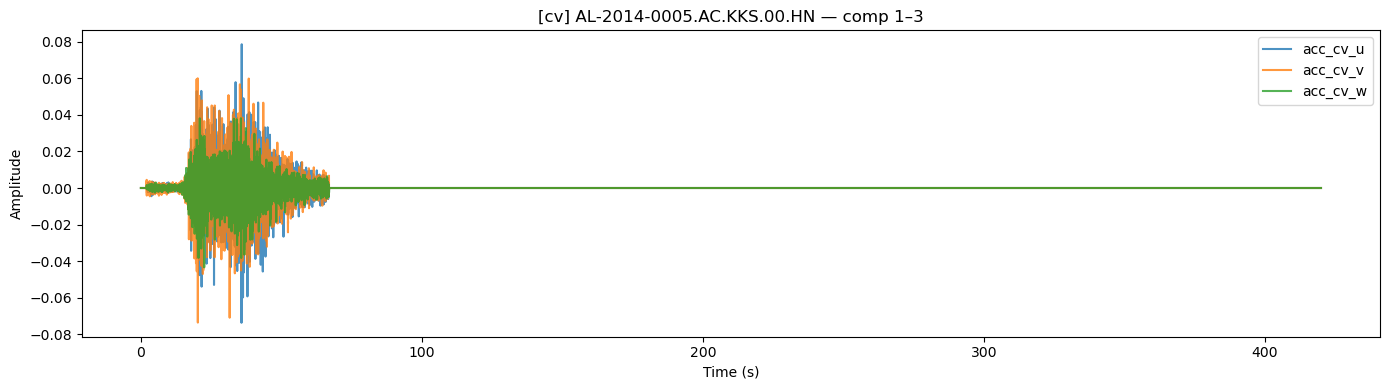

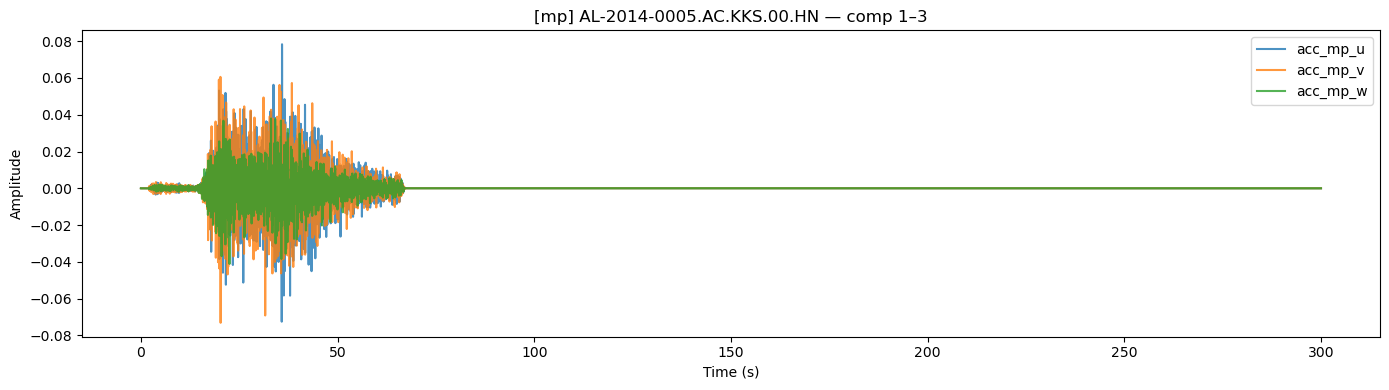

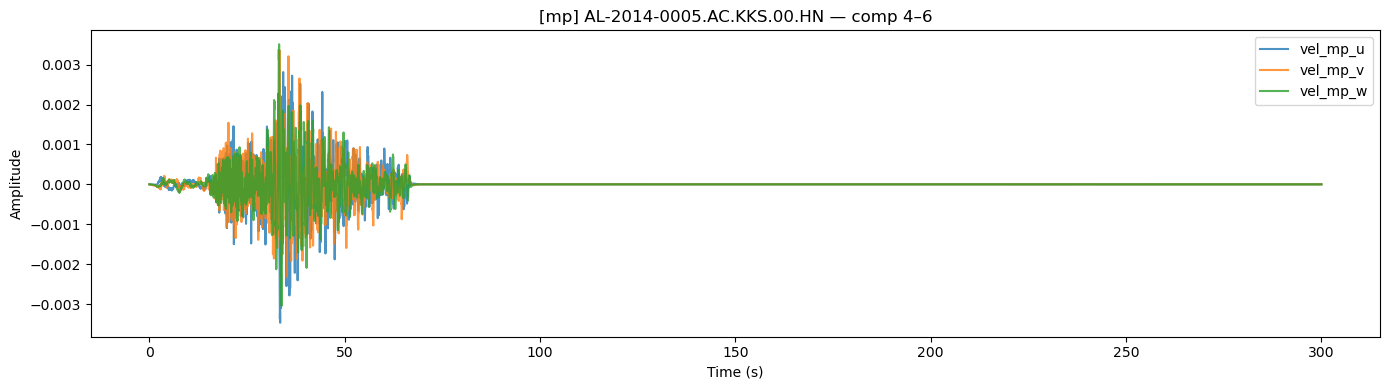

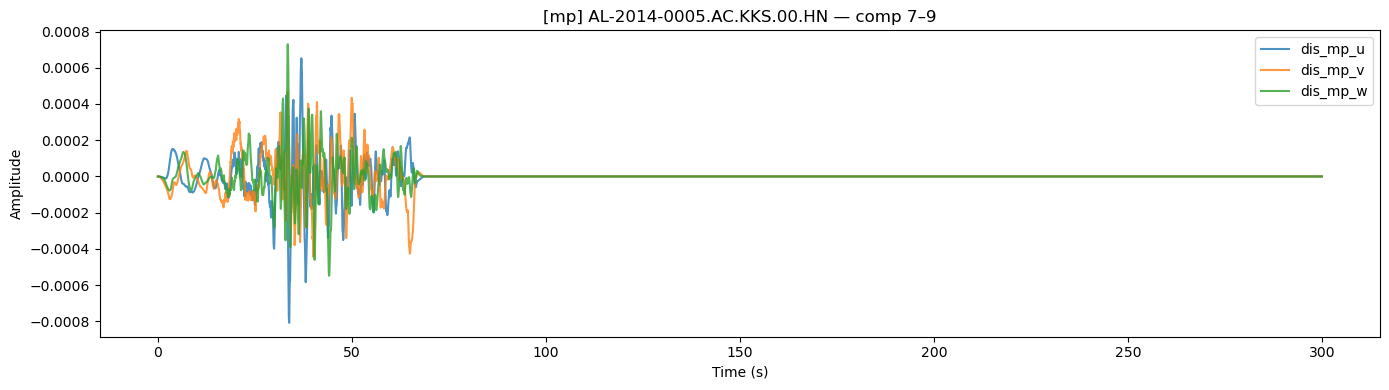

In [31]:
import matplotlib.pyplot as plt

SAMPLE_DATASET = "AL-2014-0005.AC.KKS.00.HN"  # change as needed
COMPS_PER_PLOT = 3

for label, fpath in [('cv', FILE_CV), ('mp', FILE_MP)]:
    if not os.path.exists(fpath):
        continue
    with h5py.File(fpath, 'r') as f:
        if SAMPLE_DATASET not in f['data']:
            print(f"[{label}] Dataset '{SAMPLE_DATASET}' not found.")
            continue
        data       = f['data'][SAMPLE_DATASET][()]
        comp_order = [c.decode() for c in f['data_format/component_order'][()]]
        time_s     = np.arange(data.shape[1]) / TARGET_FS

        ncomp  = data.shape[0]
        nplots = int(np.ceil(ncomp / COMPS_PER_PLOT))
        for p in range(nplots):
            start = p * COMPS_PER_PLOT
            end   = min(start + COMPS_PER_PLOT, ncomp)
            fig, ax = plt.subplots(figsize=(14, 4))
            for i in range(start, end):
                ax.plot(time_s, data[i], label=comp_order[i], alpha=0.8)
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Amplitude")
            ax.set_title(f"[{label}] {SAMPLE_DATASET} — comp {start+1}–{end}")
            ax.legend()
            plt.tight_layout()
            plt.show()

## 8. Quick HDF5 structure inspection

In [32]:
INSPECT_FILE = FILE_CV
N_SHOW       = 10

with h5py.File(INSPECT_FILE, 'r') as f:
    if 'data' in f:
        data_grp    = f['data']
        all_keys    = list(data_grp.keys())
        sample_keys = all_keys[-N_SHOW:]
        print(f"Last {N_SHOW} traces in '{os.path.basename(INSPECT_FILE)}':")
        for name in sample_keys:
            ds = data_grp[name]
            print(f"  {name:55s}  shape={ds.shape}  dtype={ds.dtype}")
    else:
        print("The 'data' group does not exist in the file.")

Last 10 traces in 'waveforms_good_cv.h5':
  TK-2013-0351.HI.RGE1..HN                                 shape=(3, 84000)  dtype=float32
  TK-2014-0250.HI.RDI1..HN                                 shape=(3, 84000)  dtype=float32
  TK-2014-0250.HL.RODB.00.HN                               shape=(3, 84000)  dtype=float32
  TK-2014-0320.HI.RGE1..HN                                 shape=(3, 84000)  dtype=float32
  TK-2015-0155.HI.RDI1..HN                                 shape=(3, 84000)  dtype=float32
  TK-2015-0155.HI.RGE1..HN                                 shape=(3, 84000)  dtype=float32
  TK-2015-0162.HI.KRL1..HN                                 shape=(3, 84000)  dtype=float32
  TK-2015-0162.HL.IKRA.00.HN                               shape=(3, 84000)  dtype=float32
  TK-2015-0162.HL.PSRA.00.HN                               shape=(3, 84000)  dtype=float32
  UZ-1976-0001.A.GZL.00.HN                                 shape=(3, 84000)  dtype=float32
